# Pipeline de imagen del nodo — Detección de la línea de horizonte

Banco de pruebas del procesamiento que corre en el **ESP32-CAM**: de un frame QVGA de
320×240 sale una **recta de horizonte** de **6 bytes**.

## Hardware del nodo

```
ESP32-CAM  ──UART──▶  Heltec WiFi LoRa 32  ──LoRa 915 MHz──▶  gateway
captura + procesa     SX1276, SOLO transmite
+ microSD             + BME280 / DS3231 / OLED por I2C
```

El reparto de tareas condiciona todo el diseño: **el ESP32-CAM procesa y almacena**, el
Heltec sólo pone la trama en el aire. Hay entonces **dos destinos con presupuestos
opuestos**:

| destino | dónde | costo | qué conviene guardar |
|---|---|---|---|
| **microSD** | en el ESP32-CAM | GB baratos, escritura local | la **grilla del índice** entera: permite re-correr el detector offline con otros umbrales |
| **enlace LoRa** | UART → Heltec → aire | airtime y ciclo de trabajo | **sólo la recta: 6 B** |

La reducción agresiva es una restricción **del enlace**, no del procesamiento ni del
almacenamiento. Es lo que separa este pipeline del de fuego, donde todo iba al aire.

El notebook responde cuatro preguntas de diseño:

1. **¿Qué índice cromático separa mejor cielo de suelo?** (de día y de noche)
2. **¿Cuánto se puede achicar la imagen sin perder el horizonte?** — es la pregunta central:
   el horizonte es una función `y(x)`, así que las **filas son resolución de medida** y las
   **columnas son sólo muestras para el ajuste**. La reducción tiene que ser *anisotrópica*.
3. **¿Qué se guarda en la SD y qué se manda por LoRa?**
4. **¿Entra en el ESP32-CAM?** — operaciones por frame, SRAM, PSRAM y milisegundos.

Todas las etapas son enteras, sin FPU y sin división en el camino caliente. La lógica vive
en `horizonte_sim.py` (mismo código que el firmware).

```
Etapa 0  captura QVGA 320x240 RGB565 (el driver la deja en PSRAM)
Etapa 1  reducción BOX a grilla gh x gw con recíproco fijo  (sin división)
Etapa 2  índice cromático cielo/suelo (1-2 ops por celda)
Etapa 3  umbral: fijo u Otsu sobre histograma de 256 bins
Etapa 4  cruce por columna + interpolación sub-celda -> perfil y(x)
Etapa 5  ajuste robusto de recta (mínimos cuadrados enteros + rechazo de outliers)
Etapa 6  registro en SD  +  trama UART al Heltec (6 B útiles) -> LoRa
```

**Ejecutar:**
```bash
cd Desarrollo/Pruebas
uv sync
uv run jupyter lab notebooks/2_horizonte.ipynb
```


In [1]:
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import ipywidgets as W
from ipywidgets import interact, IntSlider, Dropdown, Checkbox, FloatSlider

# Raíz del banco de pruebas = la carpeta que contiene `modulos/`. Así el notebook anda
# tanto abierto desde notebooks/ como desde Pruebas/.
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "modulos").is_dir()), None)
if RAIZ is None:
    raise RuntimeError(f"no encuentro 'modulos/' desde {Path.cwd()}; "
                       "abrí el notebook dentro de Desarrollo/Pruebas/")
sys.path.insert(0, str(RAIZ / "modulos"))
DATOS, SALIDAS = RAIZ / "datos", RAIZ / "salidas"


def ruta_salida(nombre):
    """Ruta dentro de salidas/, creando la carpeta si hace falta.

    Se crea al escribir y no al importar: así la celda de exportar funciona aunque
    se la ejecute sola después de reiniciar el kernel.
    """
    SALIDAS.mkdir(parents=True, exist_ok=True)
    return SALIDAS / nombre
import pipeline_sim as ps
import horizonte_sim as hs

CMAP_IDX = LinearSegmentedColormap.from_list("cielo", ["#20160c", "#7a6a4a", "#4a86c8", "#cfe4ff"])
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

W_, H_ = hs.SRC_W, hs.SRC_H


def panel(ax, data, titulo, **kw):
    ax.imshow(data, interpolation="nearest", **kw)
    ax.set_title(titulo, fontsize=9)
    ax.axis("off")


def overlay(ax, rgb, *rectas, titulo=""):
    '''Imagen QVGA con una o varias rectas (m, b, color, etiqueta) encima.'''
    ax.imshow(rgb)
    x = np.array([0.0, W_ - 1])
    for r in rectas:
        if r is None or r[0] is None:
            continue
        (m, b), color, etq = r[0], r[1], r[2]
        ax.plot(x, m * x + b, color=color, lw=1.6, label=etq)
    ax.set_xlim(0, W_ - 1); ax.set_ylim(H_ - 1, 0)
    ax.set_title(titulo, fontsize=9); ax.axis("off")
    if any(r is not None and r[0] is not None for r in rectas):
        ax.legend(fontsize=7, loc="lower left", framealpha=0.6)


def tabla(filas, cols):
    '''Impresión alineada: cols = [(titulo, ancho, formato, clave), ...]'''
    print("".join(f"{t:>{a}}" if i else f"{t:<{a}}" for i, (t, a, _, _) in enumerate(cols)))
    print("-" * sum(a for _, a, _, _ in cols))
    for f in filas:
        celdas = []
        for i, (_, a, fmt, k) in enumerate(cols):
            v = f[k] if not callable(k) else k(f)
            s = format(v, fmt) if fmt else str(v)
            celdas.append(f"{s:>{a}}" if i else f"{s:<{a}}")
        print("".join(celdas))

## 1 · Cargar la escena

Tres fuentes posibles:

- **Subir** una foto con el botón.
- **`RUTA`** apuntando a un archivo de `datos/` (por ejemplo `DATOS / "image_1.png"`).
- Sin ninguna de las dos: **escena sintética con horizonte exacto conocido**
  (`y = m·x + b`), que es lo único que permite medir el error en píxeles.

La escena sintética genera el borde con **anti-aliasing por cobertura de píxel**: sin eso
la interpolación sub-celda no tendría nada real que recuperar y las métricas saldrían
demasiado optimistas.

In [2]:
subir = W.FileUpload(accept="image/*", multiple=False, description="Subir imagen")
subir

FileUpload(value=(), accept='image/*', description='Subir imagen')

Después de subir (o de cambiar `RUTA` / los parámetros de la escena sintética),
**volvé a ejecutar la celda de abajo**: recalcula todo y el resto del notebook lee de
`rgb888`, `GT` y `REF`.

- `GT` = ground truth `(m, b)` — sólo existe en la escena sintética.
- `REF` = recta de referencia contra la que se mide todo. Si no hay ground truth, se usa
  la detección a máxima resolución vertical (240×16) como referencia.

fuente        Imagen_2.png  (320x240)
indice/metodo gris / grad   grilla nominal 120x16
ground truth  no disponible (imagen real)
referencia    y = -0.0014 x +171.63


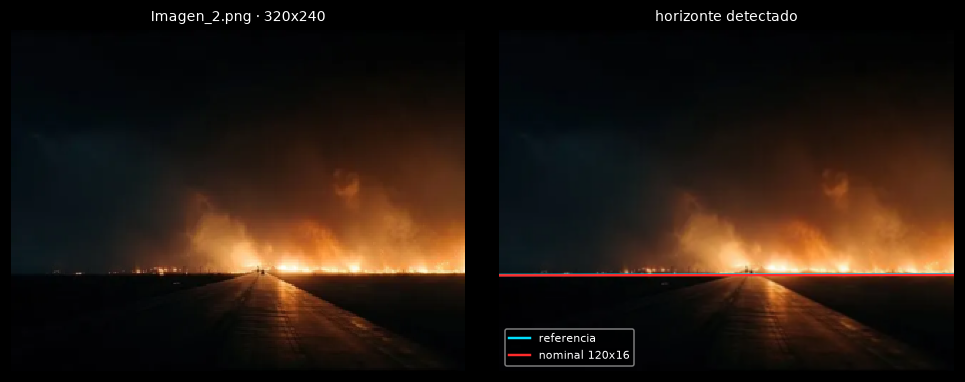

In [17]:
RUTA = subir               # p.ej. DATOS / "image_1.png"
ESCENA = dict(m=-0.08, b=118.0, noche=False, fuego=False, nubes=True, ruido=3.5)

if subir.value:
    arch = subir.value[0]
    fuente, origen = BytesIO(arch["content"]), arch["name"]
elif RUTA is not None:
    fuente, origen = RUTA, str(RUTA)
else:
    fuente, origen = None, "escena sintetica"

rgb888, GT = hs.load_qvga(fuente, **(ESCENA if fuente is None else {}))

# Índice y método nominales: cambialos acá si la escena es nocturna (ver sección 3)
INDICE, METODO = ("gris", "grad") if (GT is None or ESCENA.get("noche")) else ("B-R", "umbral")

D = hs.detectar(rgb888, hs.GRID_H, hs.GRID_W, indice=INDICE, metodo=METODO)
REF = GT if GT is not None else hs.detectar(rgb888, 240, 16, indice=INDICE, metodo=METODO)["recta"]

print(f"fuente        {origen}  ({W_}x{H_})")
print(f"indice/metodo {INDICE} / {METODO}   grilla nominal {hs.GRID_H}x{hs.GRID_W}")
print(f"ground truth  {'y = %+.4f x %+.2f' % GT if GT else 'no disponible (imagen real)'}")
print(f"referencia    {'y = %+.4f x %+.2f' % REF if REF else 'SIN DETECCION'}")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
panel(ax[0], rgb888, f"{origen} · {W_}x{H_}")
overlay(ax[1], rgb888, (REF, "#00e0ff", "referencia"), (D["recta"], "#ff2b2b", "nominal 120x16"),
        titulo="horizonte detectado")
plt.tight_layout(); plt.show()

## 2 · Etapa 0 — captura QVGA y cuantización RGB565

El sensor entrega RGB565: 5 bits de rojo, 6 de verde, 5 de azul. El firmware re-expande a
8 bits con `R<<3 | R>>2`. Interesa saber cuánto de esa cuantización se cuela en el índice
cielo/suelo: si el escalón de 8 niveles del canal azul se comiera el contraste del
horizonte, habría que capturar en otro formato.

error de cuantizacion RGB565 por canal (R,G,B): medio [3.01 1.47 3.62]  max [7 3 7]
impacto en el indice gris: MAE 1.99  max 5  (rango util del indice: 0..253)
frame crudo: 153600 B en RGB565 · 230400 B en RGB888


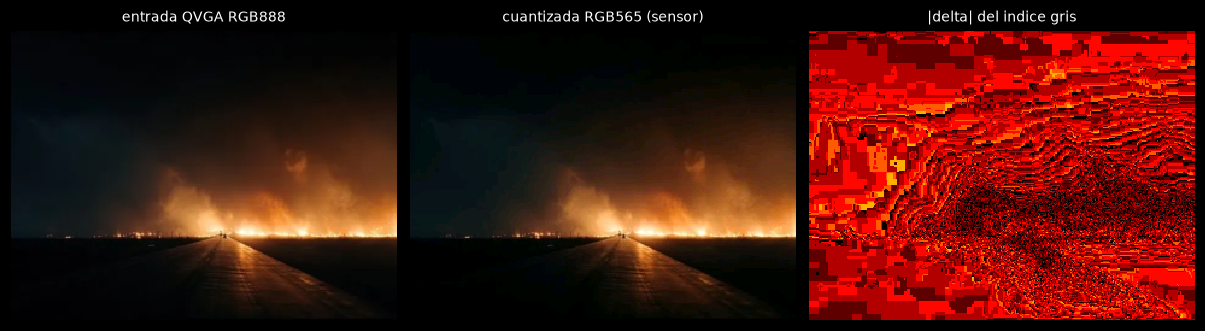

In [18]:
rgb565 = ps.to_rgb565(rgb888)
err565 = np.abs(rgb888.astype(int) - rgb565.astype(int))

i888 = hs.indices(rgb888.reshape(H_, W_, 3))[INDICE]
i565 = hs.indices(rgb565)[INDICE]
d_idx = np.abs(i888.astype(int) - i565.astype(int))

print(f"error de cuantizacion RGB565 por canal (R,G,B): "
      f"medio {err565.reshape(-1,3).mean(0).round(2)}  max {err565.reshape(-1,3).max(0)}")
print(f"impacto en el indice {INDICE}: MAE {d_idx.mean():.2f}  max {d_idx.max()}  "
      f"(rango util del indice: {i888.min()}..{i888.max()})")
print(f"frame crudo: {W_*H_*2} B en RGB565 · {W_*H_*3} B en RGB888")

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
panel(ax[0], rgb888, "entrada QVGA RGB888")
panel(ax[1], rgb565, "cuantizada RGB565 (sensor)")
panel(ax[2], d_idx, f"|delta| del indice {INDICE}", cmap="hot", vmin=0, vmax=8)
plt.tight_layout(); plt.show()

## 3 · Etapa 2 — índice cromático cielo / suelo

El horizonte se detecta sobre un escalar por celda, no sobre RGB. Candidatos, todos enteros:

| índice | cuenta | idea |
|---|---|---|
| `B-R` | 1 resta | el cielo dispersa azul, el suelo refleja rojo. El clásico diurno |
| `B-G` | 1 resta | variante contra vegetación |
| `2B-R-G` | 2 sumas + shift | exceso de azul, más robusto a la iluminación global |
| `B-max(R,G)` | 1 max + 1 resta | el más selectivo de azul; único no lineal |
| `gris` | 3 mult + shift | luminancia. No usa color: sirve de noche |

Los lineales **conmutan con el BOX** (`BOX(B-R) == BOX(B) - BOX(R)`), así que da igual
calcularlos antes o después de reducir — conviene después, sobre `gh·gw` celdas en vez de
sobre 76 800 píxeles.

La columna `sep(sigma)` es el margen entre cielo y suelo en desvíos estándar (criterio de
Fisher): cuanto más alto, mejor discrimina. `orient.` indica si el índice tuvo que
invertirse automáticamente porque el suelo salió más brillante que el cielo (típico de noche
con frente de llama).

indice          min   max  sep(sigma)  orient.  th Otsu  col.ok  inliers   MAE px
---------------------------------------------------------------------------------
B-R               0    18        0.77       no        5       5        5    86.20
B-G               0     8        0.60       no        2       1        0      nan
2B-R-G            0    12        0.76       no        3       1        0      nan
B-max(R,G)        0     8        0.60       no        2       1        0      nan
gris              0   227        0.60       si      179      16       13     0.36


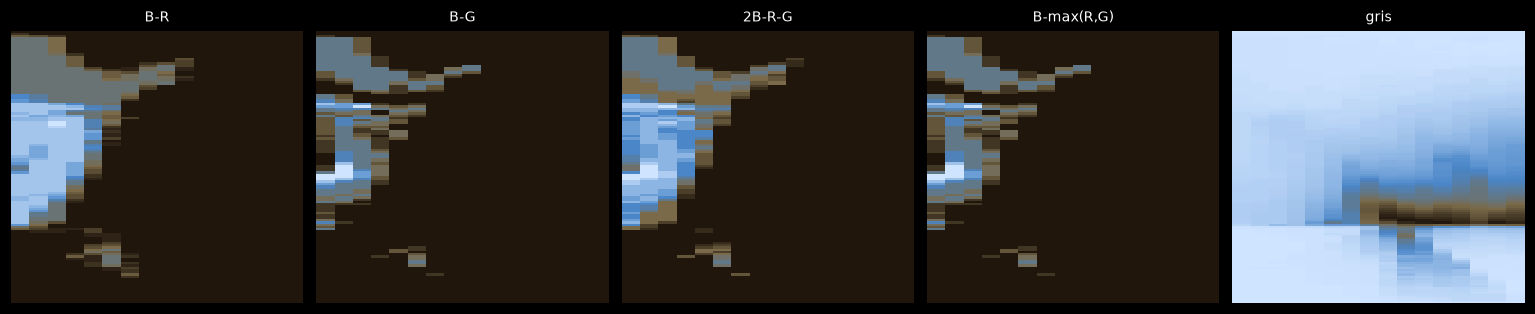


Nota: los paneles están estirados (grilla 120x16 muy alta y angosta).


In [19]:
grid_n = hs.reduce(rgb565, hs.GRID_H, hs.GRID_W)
mask_cielo_px = hs.mascara_cielo(*REF) if REF else None
mask_cielo = hs.reduce(np.repeat(mask_cielo_px[..., None], 3, 2).astype(np.uint8) * 255,
                       hs.GRID_H, hs.GRID_W)[..., 0] > 127 if REF else None

filas = []
for k, v in hs.indices(grid_n).items():
    vo, inv = hs.orientar(v)
    d = hs.detectar(rgb888, hs.GRID_H, hs.GRID_W, indice=k, metodo=METODO)
    e = hs.error_recta(d["recta"], REF)
    filas.append(dict(idx=k, mn=int(v.min()), mx=int(v.max()),
                      sep=hs.separacion(vo, mask_cielo) if mask_cielo is not None else float("nan"),
                      inv="si" if inv else "no", th=d["th"],
                      ok=int(d["ok"].sum()), inl=d["inliers"],
                      mae=e["mae"] if d["recta"] else float("nan")))

tabla(filas, [("indice", 13, "", "idx"), ("min", 6, "d", "mn"), ("max", 6, "d", "mx"),
              ("sep(sigma)", 12, ".2f", "sep"), ("orient.", 9, "", "inv"),
              ("th Otsu", 9, "d", "th"), ("col.ok", 8, "d", "ok"),
              ("inliers", 9, "d", "inl"), ("MAE px", 9, ".2f", "mae")])

fig, ax = plt.subplots(1, 5, figsize=(14, 2.9))
for a, (k, v) in zip(ax, hs.indices(grid_n).items()):
    vo, _ = hs.orientar(v)
    panel(a, vo, k, cmap=CMAP_IDX, aspect="auto")
plt.tight_layout(); plt.show()
print("\nNota: los paneles están estirados (grilla 120x16 muy alta y angosta).")

## 4 · Etapa 1 — **cuánto se puede achicar la imagen**

El punto central del diseño. Dos decisiones independientes:

**a) Forma de la grilla.** El horizonte es `y(x)`: cada fila de la grilla es un escalón de
cuantización de la posición medida, cada columna es una muestra más para el ajuste por
mínimos cuadrados. El error por cuantización cae como `1/gh`; el error por ruido cae como
`1/sqrt(gw)`. Conclusión esperable: **a igual presupuesto de celdas conviene una grilla alta
y angosta**. La tabla lo mide.

**b) Cómo se reduce cada bloque.** `box` promedia los píxeles del bloque, `decim` toma el
píxel central. La decimación es más barata y más nítida — y por eso, con ruido, mucho peor.

El barrido es **Monte Carlo sobre escenas sintéticas con horizonte aleatorio**: una sola
escena no alcanza para decidir el tamaño de grilla, porque el error depende de dónde cae el
horizonte dentro de la celda.

In [20]:
GRILLAS = [(16, 16), (16, 8), (15, 64), (30, 32), (30, 64), (24, 32),
           (48, 20), (60, 16), (120, 8), (120, 16), (240, 8), (240, 16)]
N_ESCENAS = 16

res = hs.barrido_escenas(GRILLAS, n=N_ESCENAS, indice=INDICE, metodo=METODO)
res.sort(key=lambda f: f["mae"])

print(f"Barrido sobre {N_ESCENAS} escenas sinteticas con horizonte aleatorio "
      f"(indice {INDICE}, metodo {METODO}, BOX, sub-celda ON)\n")
tabla(res, [("grilla", 12, "", lambda f: f"{f['gh']}x{f['gw']}"),
            ("celdas", 8, "d", "celdas"), ("px/fila", 9, ".1f", "px_por_fila"),
            ("MAE px", 9, ".2f", "mae"), ("p95 px", 9, ".2f", "p95"),
            ("peor px", 9, ".2f", "peor"), ("fallas", 8, "d", "fallas"),
            ("RAM B", 8, "d", "ram"), ("ms", 7, ".2f", "ms")])
print("\nRAM = acumuladores + grilla + indice + histograma (SIN framebuffer: el BOX se")
print("acumula linea a linea desde el DMA de la camara, no hace falta PSRAM).")

Barrido sobre 16 escenas sinteticas con horizonte aleatorio (indice gris, metodo grad, BOX, sub-celda ON)

grilla        celdas  px/fila   MAE px   p95 px  peor px  fallas   RAM B     ms
-------------------------------------------------------------------------------
240x16          3840      1.0     0.50     0.81     0.83       0   16112   3.38
120x16          1920      2.0     0.51     0.75     0.85       0    8432   3.14
48x20            960      5.0     0.56     0.76     0.79       0    4652   3.03
60x16            960      4.0     0.57     0.82     0.88       0    4592   3.02
30x32            960      8.0     0.70     0.93     0.97       0    4832   3.03
30x64           1920      8.0     0.72     0.92     0.93       0    9152   3.16
120x8            960      2.0     0.73     1.62     1.71       0    4472   3.02
24x32            768     10.0     0.85     1.14     1.23       0    4064   3.00
240x8           1920      1.0     0.97     2.03     2.06       0    8312   3.14
16x8         

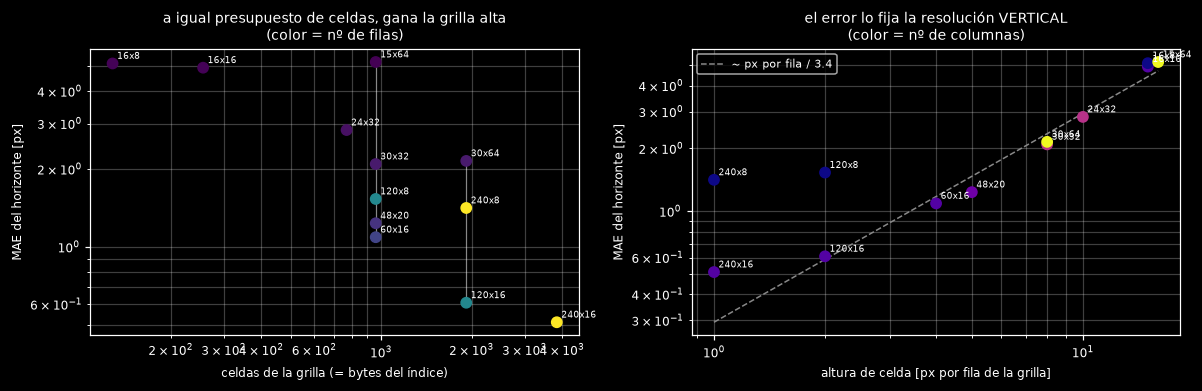

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

por_celdas = {}
for f in res:
    por_celdas.setdefault(f["celdas"], []).append(f)
ax[0].scatter([f["celdas"] for f in res], [f["mae"] for f in res],
              c=[f["gh"] for f in res], cmap="viridis", s=45, zorder=3)
for f in res:
    ax[0].annotate(f"{f['gh']}x{f['gw']}", (f["celdas"], f["mae"]), fontsize=6,
                   xytext=(3, 3), textcoords="offset points")
for c, g in por_celdas.items():          # une las grillas con el mismo presupuesto
    if len(g) > 1:
        ax[0].plot([c] * len(g), [x["mae"] for x in g], color="#888", lw=0.8, zorder=1)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("celdas de la grilla (= bytes del índice)")
ax[0].set_ylabel("MAE del horizonte [px]")
ax[0].set_title("a igual presupuesto de celdas, gana la grilla alta\n(color = nº de filas)", fontsize=9)
ax[0].grid(alpha=0.25, which="both")

ax[1].scatter([f["px_por_fila"] for f in res], [f["mae"] for f in res],
              c=[f["gw"] for f in res], cmap="plasma", s=45, zorder=3)
xx = np.array([1, 16])
ax[1].plot(xx, xx / 3.4, "--", color="#888", lw=1, label="~ px por fila / 3.4")
for f in res:
    ax[1].annotate(f"{f['gh']}x{f['gw']}", (f["px_por_fila"], f["mae"]), fontsize=6,
                   xytext=(3, 3), textcoords="offset points")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("altura de celda [px por fila de la grilla]")
ax[1].set_ylabel("MAE del horizonte [px]")
ax[1].set_title("el error lo fija la resolución VERTICAL\n(color = nº de columnas)", fontsize=9)
ax[1].legend(fontsize=7); ax[1].grid(alpha=0.25, which="both")
plt.tight_layout(); plt.show()

### 4.1 · BOX vs decimación, y el papel del ruido

Promediar el bloque cuesta una suma por píxel; decimar no cuesta nada. La diferencia
aparece con el ruido del sensor: el BOX promedia `bh·bw` píxeles y divide el ruido por
`sqrt(bh·bw)`, la decimación se lo lleva entero a la grilla. Con `ruido = 12` (sensor con
poca luz y ganancia alta) la decimación deja de servir.

grilla        box s=2    box s=6   box s=12   box s=20    decim s=2    decim s=6   decim s=12   decim s=20
----------------------------------------------------------------------------------------------------------
16x16            1.81       1.83       1.82       1.86         1.78         1.69         1.62         2.05
30x32            0.72       0.76       0.75       0.74         0.42         0.40         0.44         0.67
60x16            0.59       0.56       0.57       0.56         0.21         0.25         0.22         0.23
120x16           0.52       0.53       0.52       0.52         0.08         0.10         0.13         2.76
240x8            0.98       0.88       0.79       0.81         0.50         0.49         0.51        16.88


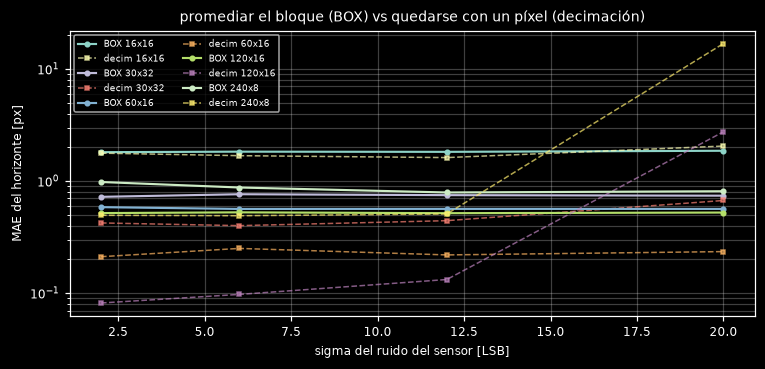

In [21]:
G_COMP = [(16, 16), (30, 32), (60, 16), (120, 16), (240, 8)]
RUIDOS = [2.0, 6.0, 12.0, 20.0]

curvas = {}
for modo in ("box", "decim"):
    for ru in RUIDOS:
        r = hs.barrido_escenas(G_COMP, n=10, ruido=ru, modo=modo,
                               indice=INDICE, metodo=METODO)
        curvas[(modo, ru)] = {(f["gh"], f["gw"]): f["mae"] for f in r}

print(f"{'grilla':<10}" + "".join(f"{f'box s={r:g}':>11}" for r in RUIDOS)
      + "".join(f"{f'decim s={r:g}':>13}" for r in RUIDOS))
print("-" * (10 + 11 * len(RUIDOS) + 13 * len(RUIDOS)))
for g in G_COMP:
    fila = f"{f'{g[0]}x{g[1]}':<10}"
    fila += "".join(f"{curvas[('box', r)][g]:>11.2f}" for r in RUIDOS)
    fila += "".join(f"{curvas[('decim', r)][g]:>13.2f}" for r in RUIDOS)
    print(fila)

fig, ax = plt.subplots(figsize=(7, 3.4))
for g in G_COMP:
    ax.plot(RUIDOS, [curvas[("box", r)][g] for r in RUIDOS], "-o", ms=3,
            lw=1.4, label=f"BOX {g[0]}x{g[1]}")
    ax.plot(RUIDOS, [curvas[("decim", r)][g] for r in RUIDOS], "--s", ms=3,
            lw=1.0, alpha=0.7, label=f"decim {g[0]}x{g[1]}")
ax.set_yscale("log"); ax.set_xlabel("sigma del ruido del sensor [LSB]")
ax.set_ylabel("MAE del horizonte [px]")
ax.set_title("promediar el bloque (BOX) vs quedarse con un píxel (decimación)", fontsize=9)
ax.legend(fontsize=6, ncol=2); ax.grid(alpha=0.25, which="both")
plt.tight_layout(); plt.show()

### 4.2 · Interpolación sub-celda: recuperar lo que el BOX no tiró

Al promediar el bloque, la celda que contiene el borde vale
`cielo·cob + suelo·(1-cob)`, con `cob` la fracción de celda que quedó del lado del cielo.
Es decir: **el promedio no destruye la posición sub-celda, la codifica en el valor**.
Basta interpolar linealmente para recuperarla, y el borde real está donde `cob = 0.5`,
o sea en el **nivel medio local** — no en el umbral global de Otsu, que cae en cualquier
lado del salto y mete un sesgo fijo.

Coste: dos lecturas, una suma, un shift y una división por columna.

grilla      px/fila   sin sub-celda   con sub-celda    mejora
-------------------------------------------------------------
16x16          15.0            2.11            1.78       16%
16x8           15.0            2.02            1.29       36%
30x32           8.0            0.65            0.72      -10%
60x16           4.0            0.58            0.59       -1%
120x16          2.0            0.52            0.52       -1%
240x8           1.0            1.01            1.00        2%


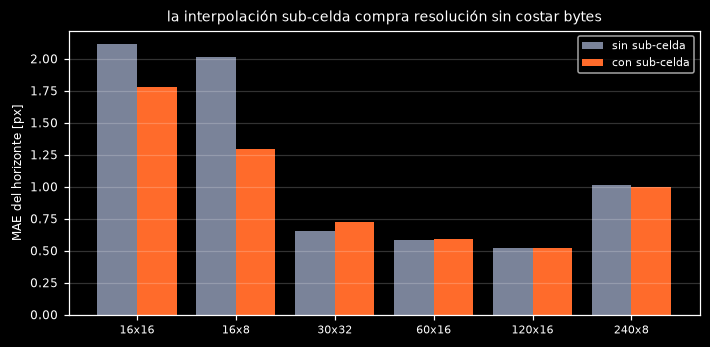

In [22]:
G_SUB = [(16, 16), (16, 8), (30, 32), (60, 16), (120, 16), (240, 8)]
con = {(f["gh"], f["gw"]): f["mae"] for f in
       hs.barrido_escenas(G_SUB, n=12, subcelda=True, indice=INDICE, metodo=METODO)}
sin = {(f["gh"], f["gw"]): f["mae"] for f in
       hs.barrido_escenas(G_SUB, n=12, subcelda=False, indice=INDICE, metodo=METODO)}

print(f"{'grilla':<10}{'px/fila':>9}{'sin sub-celda':>16}{'con sub-celda':>16}{'mejora':>10}")
print("-" * 61)
for g in G_SUB:
    a, b = sin[g], con[g]
    print(f"{f'{g[0]}x{g[1]}':<10}{H_/g[0]:>9.1f}{a:>16.2f}{b:>16.2f}{100*(1-b/a):>9.0f}%")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
xs = np.arange(len(G_SUB))
ax.bar(xs - 0.2, [sin[g] for g in G_SUB], 0.4, label="sin sub-celda", color="#7a8399")
ax.bar(xs + 0.2, [con[g] for g in G_SUB], 0.4, label="con sub-celda", color="#ff6b2b")
ax.set_xticks(xs, [f"{g[0]}x{g[1]}" for g in G_SUB], fontsize=7)
ax.set_ylabel("MAE del horizonte [px]"); ax.legend(fontsize=7); ax.grid(alpha=0.2, axis="y")
ax.set_title("la interpolación sub-celda compra resolución sin costar bytes", fontsize=9)
plt.tight_layout(); plt.show()

## 5 · Etapas 3 y 4 — umbral y perfil por columna

**Umbral.** Otsu sobre un histograma de 256 bins (512 B de RAM, una pasada por la grilla)
se adapta solo a la hora del día y a la niebla; el umbral fijo es más barato pero hay que
recalibrarlo. Movés el slider con `Otsu` destildado para ver la sensibilidad.

**Detección por columna.** Dos métodos:

- **`umbral`** — cruce descendente del umbral **con mayor salto** (no el primero: un cielo
  con degradé o con nubes cruza el umbral varias veces y el primer cruce caería dentro del
  cielo). Una comparación por celda.
- **`grad`** — máximo del gradiente vertical, con interpolación parabólica de 3 puntos.
  No necesita que el cielo sea globalmente más brillante: es el que aguanta las escenas
  nocturnas, donde el frente de llama invierte el contraste.

Una columna se descarta si el salto no llega a `th_contraste`: es lo que evita que un árbol,
una nube baja o una columna saturada metan un punto falso en el ajuste.

In [ ]:
@interact(gh=Dropdown(options=hs.FILAS_OK, value=hs.GRID_H, description="filas"),
          gw=Dropdown(options=hs.COLS_OK, value=hs.GRID_W, description="columnas"),
          indice=Dropdown(options=list(hs.indices(grid_n)), value=INDICE, description="índice"),
          metodo=Dropdown(options=("umbral", "grad"), value=METODO, description="método"),
          modo=Dropdown(options=("box", "decim"), value="box", description="reducción"),
          usar_otsu=Checkbox(value=True, description="umbral Otsu"),
          th_manual=IntSlider(40, 0, 255, 1, description="th fijo"),
          th_contraste=IntSlider(hs.TH_CONTRASTE, 0, 60, 1, description="contraste mín"),
          subcelda=Checkbox(value=True, description="sub-celda"))
def explorar(gh, gw, indice, metodo, modo, usar_otsu, th_manual, th_contraste, subcelda):
    d = hs.detectar(rgb888, gh, gw, indice, modo, metodo,
                    None if usar_otsu else th_manual, th_contraste, subcelda)
    e = hs.error_recta(d["recta"], REF)

    fig = plt.figure(figsize=(13, 3.6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1.1, 0.55, 1.1, 1.4])
    a0, a1, a2, a3 = (fig.add_subplot(gs[i]) for i in range(4))

    panel(a0, d["grid"], f"grilla {gh}x{gw} ({modo})", aspect="auto")
    panel(a1, d["idx"], f"índice {indice}" + (" (inv)" if d["invertido"] else ""),
          cmap=CMAP_IDX, aspect="auto")

    # perfil de la columna del medio
    c = gw // 2
    p = d["idx"][:, c]
    a2.plot(p, np.arange(gh), lw=1.2, color="#4a86c8")
    a2.axvline(d["th"], color="#ff6b2b", ls="--", lw=1, label=f"th={d['th']}")
    if d["ok"][c]:
        a2.axhline(d["y_celda"][c], color="#ff2b2b", lw=1, label=f"y={d['y_celda'][c]:.2f}")
    a2.invert_yaxis(); a2.set_xlabel("índice"); a2.set_ylabel("fila de grilla")
    a2.set_title(f"perfil de la columna {c}", fontsize=9)
    a2.legend(fontsize=6); a2.grid(alpha=0.2)

    overlay(a3, rgb888, (REF, "#00e0ff", "referencia"), (d["recta"], "#ff2b2b", "detectado"),
            titulo="resultado")
    if d["ok"].any():
        x_ok, y_ok = hs.a_pixeles(d["y_celda"], d["ok"], gh, gw)
        a3.scatter(x_ok, y_ok, s=14, c="#ffd166", zorder=4, label="perfil")
    plt.tight_layout(); plt.show()

    print(f"umbral usado {d['th']}  ({'Otsu' if usar_otsu else 'fijo'})   "
          f"índice invertido: {d['invertido']}")
    print(f"columnas válidas {int(d['ok'].sum())}/{gw}   inliers {d['inliers']}   "
          f"paquete {len(d['pkt'])} B")
    if d["recta"]:
        m, b = d["recta"]
        print(f"recta y = {m:+.4f} x {b:+.2f}   inclinación {np.degrees(np.arctan(m)):+.2f} deg")
        print(f"vs referencia: MAE {e['mae']:.2f} px   máx {e['emax']:.2f} px   "
              f"ángulo {e['ang']:.2f} deg")
    else:
        print("SIN HORIZONTE -> early exit, trama de 1 byte")

interactive(children=(Dropdown(description='filas', index=9, options=(15, 16, 20, 24, 30, 40, 48, 60, 80, 120,…

## 6 · Etapa 5 — ajuste robusto de la recta

Mínimos cuadrados sobre los puntos válidos: cuatro acumuladores enteros (`Sx, Sy, Sxx, Sxy`)
y dos divisiones para toda la imagen. Después, **una pasada de rechazo de outliers**: se
descartan los puntos con `|residuo| > 2 · error medio absoluto` y se reajusta.

Se usa la media de `|residuo|` en vez de la mediana (MAD) para no ordenar en el ESP32; con
más de 8 columnas válidas la diferencia es despreciable. Si aparecieran escenas con más del
30 % de outliers (bosque cerrado, edificios), hay que pasar a MAD — es un `sort` de `gw`
elementos.

In [24]:
@interact(k=FloatSlider(value=hs.K_OUTLIER, min=0.5, max=5.0, step=0.1, description="k · MAE"),
          gw=Dropdown(options=hs.COLS_OK, value=hs.GRID_W, description="columnas"))
def ver_ajuste(k, gw):
    d = hs.detectar(rgb888, hs.GRID_H, gw, INDICE, metodo=METODO)
    x, y = d["x_px"], d["y_px"]
    if x.size < hs.MIN_INLIERS:
        print("muy pocas columnas válidas para ajustar"); return

    crudo = hs.fit_line(x, y)
    rob = hs.fit_line_robust(x, y, k=k)
    recta = (rob[0], rob[1]) if rob else None
    keep = rob[3] if rob else np.ones(x.size, bool)

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    overlay(ax[0], rgb888, (REF, "#00e0ff", "referencia"),
            (crudo, "#7a8399", "LS crudo"), (recta, "#ff2b2b", "LS robusto"),
            titulo="ajuste")
    ax[0].scatter(x[keep], y[keep], s=18, c="#ffd166", zorder=4, label="inliers")
    ax[0].scatter(x[~keep], y[~keep], s=28, c="#ff2b2b", marker="x", zorder=5, label="outliers")

    if recta:
        r = y - (recta[0] * x + recta[1])
        ax[1].stem(x, r, basefmt=" ")
        ax[1].axhline(0, color="#7a8399", lw=0.8)
        ax[1].axhline(k * np.abs(r[keep]).mean(), color="#ff2b2b", ls="--", lw=0.8,
                      label="umbral de rechazo")
        ax[1].axhline(-k * np.abs(r[keep]).mean(), color="#ff2b2b", ls="--", lw=0.8)
        ax[1].set_xlabel("x [px]"); ax[1].set_ylabel("residuo [px]")
        ax[1].set_title("residuos del ajuste", fontsize=9)
        ax[1].legend(fontsize=7); ax[1].grid(alpha=0.2)
    plt.tight_layout(); plt.show()

    for nombre, r in (("LS crudo", crudo), ("LS robusto", recta)):
        e = hs.error_recta(r, REF)
        print(f"{nombre:<12} y = {r[0]:+.4f} x {r[1]:+7.2f}   "
              f"MAE vs referencia {e['mae']:6.2f} px   ángulo {e['ang']:5.2f} deg")
    print(f"inliers {int(keep.sum())}/{x.size}")

interactive(children=(FloatSlider(value=2.0, description='k · MAE', max=5.0, min=0.5), Dropdown(description='c…

## 7 · Etapa 6 — las dos salidas del nodo

### 7.1 · Al aire: UART → Heltec → LoRa

Lo que sale del ESP32-CAM hacia el Heltec es la recta, no la imagen:

| campo | tipo | bytes |
|---|---|---|
| flags | uint8 | 1 |
| pendiente `m` | Q8.8 (int16) | 2 |
| offset `b` | Q14.2 (int16) | 2 |
| inliers | uint8 | 1 |
| **payload** | | **6** |

`Q8.8` da un paso de pendiente de 1/256 (≈ 0.22° de inclinación); `Q14.2` da un paso de
offset de 0.25 px.

Como son **dos placas separadas unidas por un cable**, el payload viaja envuelto en una
trama con `SOF | tipo | len | payload | CRC8` — 4 bytes de sobre. El CRC no es opcional:
una trama de 6 B corrupta se transmitiría igual y llegaría al gateway como un horizonte
válido pero equivocado. El Heltec valida antes de poner nada en el aire.

La tabla compara contra transmitir la imagen a distintos niveles de reducción, con el
airtime a **SF10 / 125 kHz / CR 4:5**.

In [25]:
@interact(payload_mtu=IntSlider(222, 32, 255, 10, description="Payload MTU (B)"))
def evaluar_lora(payload_mtu):
    formatos = [
        ("QVGA RGB888 cruda (320x240)", W_ * H_ * 3),
        ("QVGA RGB565 cruda (320x240)", W_ * H_ * 2),
        ("Grilla 120x16 RGB (tras BOX)", 120 * 16 * 3),
        ("Índice 120x16 uint8", 120 * 16),
        ("Índice 16x16 uint8 (grilla del pipeline de fuego)", 16 * 16),
        ("Perfil del horizonte: 1 byte por columna (16 col.)", 16),
        ("PAQUETE HORIZONTE (recta 6 B)", 6),
        ("Early exit (sin horizonte)", 1),
    ]
    base = W_ * H_ * 2
    print(f"{'Formato':<52}{'Bytes':>8}{'vs QVGA':>10}{'Paquetes':>10}{'Airtime':>14}")
    print("-" * 94)
    for nombre, b in formatos:
        a = ps.lora_packet_analysis(b, payload_mtu=payload_mtu)
        t = a["total_airtime"]
        ts = f"{t/60:.2f} min" if t >= 60 else f"{t*1000:.1f} ms"
        print(f"{nombre:<52}{b:>8}{base/b:>9.0f}x{a['num_packets']:>10}{ts:>14}")
    print("-" * 94)
    print("La imagen cruda son ~700 paquetes y decenas de minutos al aire: inviable por")
    print("consumo y por ciclo de trabajo regulatorio. La recta entra en un paquete de 6 B.")

if D["recta"] is not None:
    trama = hs.pack_uart(D["pkt"])
    print(f"\nTrama UART al Heltec ({len(trama)} B): {trama.hex(' ')}")
    print(f"  SOF {trama[0]:02x} | tipo {trama[1]:02x} | len {trama[2]} | "
          f"payload {D['pkt'].hex(' ')} | CRC8 {trama[-1]:02x}")
    print(f"  a {hs.UART_BAUD} baudios (8N1): {10*len(trama)/hs.UART_BAUD*1000:.2f} ms de enlace,")
    print(f"  contra {ps.lora_airtime(len(D['pkt']))*1000:.1f} ms de airtime LoRa. El cable no es el cuello de botella.")
    print(f"  verificacion: {hs.unpack_uart(trama)[1] == D['pkt']}   "
          f"con 1 bit dado vuelta: {hs.unpack_uart(bytes([trama[0], trama[1]^1]) + trama[2:])}")

interactive(children=(IntSlider(value=222, description='Payload MTU (B)', max=255, min=32, step=10), Output())…


Trama UART al Heltec (10 B): a5 01 06 01 00 00 b0 02 0d 15
  SOF a5 | tipo 01 | len 6 | payload 01 00 00 b0 02 0d | CRC8 15
  a 115200 baudios (8N1): 0.87 ms de enlace,
  contra 247.8 ms de airtime LoRa. El cable no es el cuello de botella.
  verificacion: True   con 1 bit dado vuelta: None


### 7.2 · A la microSD: qué conviene conservar

La SD del ESP32-CAM cambia el planteo respecto del pipeline de fuego. Guardar localmente
sirve para dos cosas concretas:

- **Recalibrar offline.** Si se guarda la **grilla del índice** entera (`gh·gw` bytes), se
  puede volver a correr *este mismo notebook* sobre datos de campo reales y reelegir el
  índice, el umbral y el método sin volver a salir a buscar imágenes.
- **Store-and-forward.** Si el enlace LoRa se cae o el ciclo de trabajo ya se agotó, el
  registro queda en la tarjeta y la recta se retransmite cuando el enlace vuelve. Sin SD,
  esa captura se pierde.

Las políticas van de guardar sólo el resultado a guardar el frame crudo. El cálculo redondea
cada registro al **sector de 512 B de FAT**: con registros de decenas de bytes el desperdicio
domina y conviene agrupar varias capturas por escritura en vez de un `fwrite` por captura
(además, cada escritura despierta la tarjeta y cuesta ~100 mA — entra en el balance solar).

interactive(children=(IntSlider(value=1440, description='capturas/día', max=8640, min=24, step=24), Dropdown(d…

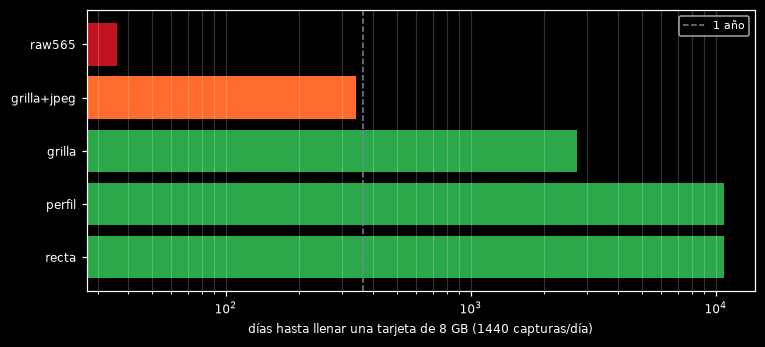

In [27]:
@interact(capturas_dia=IntSlider(1440, 24, 8640, 24, description="capturas/día"),
          tarjeta_gb=Dropdown(options=(2, 4, 8, 16, 32), value=8, description="tarjeta GB"),
          jpeg_kb=IntSlider(14, 4, 40, 1, description="JPEG kB"))
def presupuesto(capturas_dia, tarjeta_gb, jpeg_kb):
    print(f"grilla {hs.GRID_H}x{hs.GRID_W} · {capturas_dia} capturas/día · tarjeta {tarjeta_gb} GB\n")
    print(f"{'política':<14}{'B/captura':>11}{'con sector':>12}{'MB/día':>10}{'duración':>14}   qué habilita")
    print("-" * 108)
    ayuda = {
        "recta": "serie temporal del horizonte",
        "perfil": "+ ver si el terreno no es recto",
        "grilla": "+ RE-CORRER el detector offline con otros umbrales",
        "grilla+jpeg": "+ verdad visual para el informe",
        "raw565": "sólo para depurar el driver de cámara",
    }
    for pol in hs.POLITICAS_SD:
        s = hs.presupuesto_sd(pol, hs.GRID_H, hs.GRID_W, capturas_dia, tarjeta_gb, jpeg_kb)
        d = s["dias_sector"]
        dur = f"{d/365:.1f} años" if d > 730 else f"{d:.0f} días"
        print(f"{pol:<14}{s['bytes_registro']:>11,}{s['bytes_con_sector']:>12,}"
              f"{s['bytes_dia_sector']/1e6:>10.2f}{dur:>14}   {ayuda[pol]}")
    print("-" * 108)
    reco = hs.presupuesto_sd("grilla", hs.GRID_H, hs.GRID_W, capturas_dia, tarjeta_gb)
    print(f"Guardar la grilla entera ({hs.GRID_H*hs.GRID_W} B) llena la tarjeta recién en "
          f"{reco['dias_sector']/365:.1f} años:")
    print("no hay razón para tirar el índice en el nodo. Lo que hay que achicar es el ENLACE.")

fig, ax = plt.subplots(figsize=(7, 3.2))
pols = list(hs.POLITICAS_SD)
dias = [hs.presupuesto_sd(p, hs.GRID_H, hs.GRID_W)["dias_sector"] for p in pols]
ax.barh(pols, dias, color=["#2ba84a", "#2ba84a", "#2ba84a", "#ff6b2b", "#c1121f"])
ax.axvline(365, color="#7a8399", ls="--", lw=1, label="1 año")
ax.set_xscale("log"); ax.set_xlabel("días hasta llenar una tarjeta de 8 GB (1440 capturas/día)")
ax.legend(fontsize=7); ax.grid(alpha=0.2, axis="x", which="both")
plt.tight_layout(); plt.show()

## 8 · Receptor — qué se pierde al cuantizar la recta

El receptor desempaqueta `m` y `b` y reconstruye el horizonte. La única pérdida que agrega
esta etapa es la cuantización de los dos enteros: se mide barriendo pendientes y offsets en
todo el rango útil.

error de cuantización Q8.8 / Q14.2 sobre 4961 rectas:
  MAE medio 0.156 px   peor caso 0.299 px
  paso de pendiente 1/256 = 0.224 deg   paso de offset 0.25 px

escena actual:
  TX  y = -0.0010 x +171.93   MAE vs referencia 0.36 px
  RX  y = +0.0000 x +172.00   MAE vs referencia 0.59 px
  paquete: 01 00 00 b0 02 0d  (6 B, inliers 13)


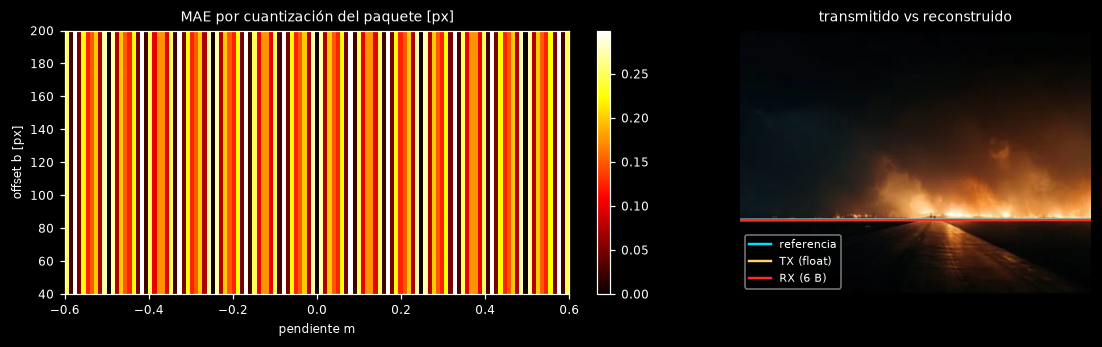

In [28]:
ms = np.linspace(-0.6, 0.6, 121)
bs = np.linspace(40, 200, 41)
err = np.array([[hs.error_recta((m, b), hs.unpack(hs.pack(m, b, 16))[:2])["mae"]
                 for b in bs] for m in ms])

print(f"error de cuantización Q8.8 / Q14.2 sobre {err.size} rectas:")
print(f"  MAE medio {err.mean():.3f} px   peor caso {err.max():.3f} px")
print(f"  paso de pendiente 1/256 = {np.degrees(np.arctan(1/256)):.3f} deg   "
      f"paso de offset 0.25 px")

if D["recta"]:
    m_rx, b_rx, inl = hs.unpack(D["pkt"])
    e_tx = hs.error_recta(D["recta"], REF)
    e_rx = hs.error_recta((m_rx, b_rx), REF)
    print(f"\nescena actual:")
    print(f"  TX  y = {D['recta'][0]:+.4f} x {D['recta'][1]:+.2f}   MAE vs referencia {e_tx['mae']:.2f} px")
    print(f"  RX  y = {m_rx:+.4f} x {b_rx:+.2f}   MAE vs referencia {e_rx['mae']:.2f} px")
    print(f"  paquete: {D['pkt'].hex(' ')}  ({len(D['pkt'])} B, inliers {inl})")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
im = ax[0].imshow(err.T, aspect="auto", origin="lower", cmap="hot",
                  extent=[ms[0], ms[-1], bs[0], bs[-1]])
ax[0].set_xlabel("pendiente m"); ax[0].set_ylabel("offset b [px]")
ax[0].set_title("MAE por cuantización del paquete [px]", fontsize=9)
plt.colorbar(im, ax=ax[0], fraction=0.046)

if D["recta"]:
    m_rx, b_rx, _ = hs.unpack(D["pkt"])
    overlay(ax[1], rgb888, (REF, "#00e0ff", "referencia"),
            (D["recta"], "#ffd166", "TX (float)"), ((m_rx, b_rx), "#ff2b2b", "RX (6 B)"),
            titulo="transmitido vs reconstruido")
else:
    ax[1].axis("off")
plt.tight_layout(); plt.show()

## 9 · Costo en el ESP32-CAM

El término dominante es fijo: la pasada BOX sobre los 76 800 píxeles del frame. **No depende
del tamaño de la grilla**, así que subir de 16×16 a 120×16 casi no cuesta tiempo — sólo SRAM.
Es la razón por la que conviene gastar el presupuesto en filas.

**Dos presupuestos de memoria distintos.** El driver `esp32-camera` deja el frame QVGA
RGB565 completo en la **PSRAM** de la placa (153 600 B); el pipeline lo recorre *in-place* y
no pide ningún buffer extra. Lo que sale de la **SRAM** son sólo la grilla, el índice, el
histograma y el perfil — unos pocos kB.

Existe una variante `stream` que procesa por callback de línea del DMA y no retiene el frame:
ahorra la PSRAM, pero deja al nodo **sin la imagen para guardar en la SD ni para comprimir a
JPEG**. Dado que la placa ya tiene PSRAM y que la SD es el argumento para conservar
evidencia, el camino normal es `fb`.

El cálculo de tiempo asume ~3 ciclos por operación a 240 MHz; es una cota gruesa (la pasada
BOX es limitada por memoria, no por ALU), sirve para comparar configuraciones entre sí, no
como número absoluto. No incluye la escritura en SD ni el JPEG, que son los que realmente
mandan en el consumo por captura.

grilla 120x16 · método grad · Otsu ON

etapa                          operaciones  % del total
-------------------------------------------------------
BOX: acumular frame                230,400        91.6%
BOX: normalizar                     11,520         4.6%
indice cromatico                     3,840         1.5%
histograma + Otsu                    3,456         1.4%
perfil por columna                   2,112         0.8%
ajuste robusto                         200         0.1%
-------------------------------------------------------
TOTAL                              251,528       100.0%

~3.1 ms por frame @240 MHz (3 ciclos/op)   20 divisiones enteras

SRAM del pipeline                   bytes
-----------------------------------------
acumuladores de fila (int32)          192
grilla (uint8 RGB)                   5760
indice (uint8)                       1920
histograma (uint16)                   512
perfil y validez                       48
----------------------------------------

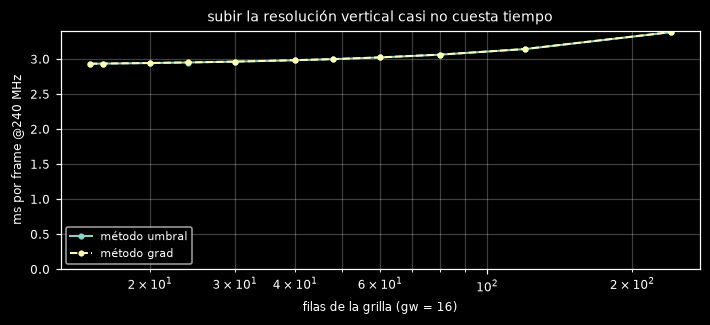

In [29]:
c = hs.costo_esp32(hs.GRID_H, hs.GRID_W, METODO)
print(f"grilla {hs.GRID_H}x{hs.GRID_W} · método {METODO} · Otsu ON\n")
print(f"{'etapa':<28}{'operaciones':>14}{'% del total':>13}")
print("-" * 55)
for k, v in c["ops"].items():
    print(f"{k:<28}{v:>14,}{100*v/c['total_ops']:>12.1f}%")
print("-" * 55)
print(f"{'TOTAL':<28}{c['total_ops']:>14,}{100:>12.1f}%")
print(f"\n~{c['ms']:.1f} ms por frame @240 MHz (3 ciclos/op)   {c['divisiones']} divisiones enteras")

print(f"\n{'SRAM del pipeline':<32}{'bytes':>9}")
print("-" * 41)
for k, v in c["ram"].items():
    print(f"{k:<32}{v:>9}")
print("-" * 41)
print(f"{'TOTAL SRAM':<32}{c['ram_total']:>9}")
print(f"{'PSRAM (framebuffer del driver)':<32}{c['psram']:>9}")

cst = hs.costo_esp32(hs.GRID_H, hs.GRID_W, METODO, origen="stream")
print(f"\n{'origen del frame':<12}{'SRAM':>10}{'PSRAM':>12}   qué habilita")
print("-" * 70)
print(f"{'fb':<12}{c['ram_total']:>10,}{c['psram']:>12,}   guardar en SD, JPEG, reprocesar")
print(f"{'stream':<12}{cst['ram_total']:>10,}{cst['psram']:>12,}   sólo la recta: la imagen se pierde")
print("\nEl ESP32-CAM ya trae PSRAM y la SD es la razón para conservar la imagen:")
print("el camino normal es 'fb'. 'stream' queda como plan B si la PSRAM hace falta para otra cosa.")

fig, ax = plt.subplots(figsize=(6.5, 3))
for met, ls in (("umbral", "-"), ("grad", "--")):
    ax.plot([g for g, _ in [(gh, 0) for gh in hs.FILAS_OK]],
            [hs.costo_esp32(gh, hs.GRID_W, met)["ms"] for gh in hs.FILAS_OK],
            ls, marker="o", ms=3, lw=1.3, label=f"método {met}")
ax.set_xscale("log"); ax.set_xlabel("filas de la grilla (gw = 16)")
ax.set_ylabel("ms por frame @240 MHz"); ax.set_ylim(0, None)
ax.set_title("subir la resolución vertical casi no cuesta tiempo", fontsize=9)
ax.legend(fontsize=7); ax.grid(alpha=0.25, which="both")
plt.tight_layout(); plt.show()

## 10 · Exportar — un archivo por destino

Se escriben los tres artefactos que produce una captura real del nodo:

- `registro_sd.bin` — lo que va a la **microSD** con la política `grilla`: cabecera + recta +
  perfil + el índice `gh×gw` entero. Es el que permite volver a correr este notebook sobre
  datos de campo y reelegir umbrales sin salir a sacar fotos de nuevo.
- `trama_uart.bin` — la trama con `SOF | tipo | len | payload | CRC8` que el ESP32-CAM manda
  al Heltec por el cable.
- `perfil_horizonte.csv` — el perfil `x_px, y_px, inlier` en texto, para comparar el volcado
  UART de depuración del firmware contra esta simulación.

In [16]:
if D["recta"] is None:
    print("sin detección: nada para exportar (el nodo mandaría 1 byte de early exit)")
else:
    m, b = D["recta"]

    # perfil en texto (depuración)
    perfil = np.column_stack([D["x_px"], D["y_px"], D["keep"].astype(int)])
    csv_perfil = ruta_salida("perfil_horizonte.csv")
    np.savetxt(csv_perfil, perfil, fmt="%.3f,%.3f,%d",
               header="x_px,y_px,inlier", comments="")

    # trama al Heltec
    trama = hs.pack_uart(D["pkt"])
    ruta_salida("trama_uart.bin").write_bytes(trama)

    # registro para la SD, política "grilla"
    y_q4 = np.zeros(D["gw"], np.int16)
    y_q4[D["ok"]] = np.clip(np.round(D["y_px"] * 4), -32768, 32767).astype(np.int16)
    reg = (bytes(12)                                  # timestamp DS3231 + contador + flags
           + D["pkt"]                                 # la recta
           + y_q4.astype("<i2").tobytes()             # perfil y(x) en Q14.2
           + D["idx"].astype(np.uint8).tobytes())     # el índice completo
    ruta_salida("registro_sd.bin").write_bytes(reg)
    esperado = hs.bytes_por_registro("grilla", D["gh"], D["gw"])
    assert len(reg) == esperado, f"registro {len(reg)} B, el presupuesto dice {esperado} B"

    print(f"{'archivo':<24}{'bytes':>9}   destino")
    print("-" * 66)
    print(f"{'registro_sd.bin':<24}{len(reg):>9}   microSD del ESP32-CAM")
    print(f"{'trama_uart.bin':<24}{len(trama):>9}   cable al Heltec  ({trama.hex(' ')})")
    print(f"{'perfil_horizonte.csv':<24}"
          f"{csv_perfil.stat().st_size:>9}   depuración / comparación")
    print("-" * 66)
    print(f"recta y = {m:+.4f} x {b:+.2f}   inliers {D['inliers']}/{D['gw']}")
    print(f"\nal aire van {len(D['pkt'])} B de los {W_*H_*2:,} B del frame = "
          f"{W_*H_*2/len(D['pkt']):,.0f}x")
    print(f"en la SD quedan {len(reg)} B, que alcanzan para reconstruir y recalibrar todo.")

archivo                     bytes   destino
------------------------------------------------------------------
registro_sd.bin              1970   microSD del ESP32-CAM
trama_uart.bin                 10   cable al Heltec  (a5 01 06 01 eb ff d9 01 0e 89)
perfil_horizonte.csv          295   depuración / comparación
------------------------------------------------------------------
recta y = -0.0823 x +118.13   inliers 14/16

al aire van 6 B de los 153,600 B del frame = 25,600x
en la SD quedan 1970 B, que alcanzan para reconstruir y recalibrar todo.
